# Objective 4 — Reviewer Behavior Analysis

In this section, we analyze reviewer behavior in the beer review dataset. 
The goal is to understand whether certain reviewers show rating biases and whether experienced reviewers rate beers differently.

Key questions explored:
- Who are the most active reviewers?
- Do some reviewers consistently rate beers higher or lower than others?
- Does reviewer experience affect rating behavior?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loding the cleaned dataset

In [10]:
df=pd.read_csv("Datasets/beer.csv")
df.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,1,Sausa Weizen,stcules,1.5,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,2.0,2.5,1.5,1.5
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,2.5,3.0,3.0,3.0
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,5,Cauldron Dipa,johnmichaelsen,4.0,Unknown,AMERICAN IPA,<bound method Series.median of 0 NaN...,4.5,4.0,4.5,4.0


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251441 entries, 0 to 251440
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   review_id          251441 non-null  int64  
 1   beer_name          251441 non-null  object 
 2   reviewer_username  251441 non-null  object 
 3   overall_score      251441 non-null  float64
 4   brewery_name       251441 non-null  object 
 5   beer_style         251441 non-null  object 
 6   beer_abv           251441 non-null  object 
 7   aroma_score        251441 non-null  float64
 8   appearance_score   251441 non-null  float64
 9   taste_score        251441 non-null  float64
 10  palate_score       251441 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 21.1+ MB


In [12]:
df.columns

Index(['review_id', 'beer_name', 'reviewer_username', 'overall_score',
       'brewery_name', 'beer_style', 'beer_abv', 'aroma_score',
       'appearance_score', 'taste_score', 'palate_score'],
      dtype='object')

Reviewer activity analysis
-Analyzing how many reviews each reviewer has left to idenfity most active reviewers

In [14]:
review_counts=df.groupby("reviewer_username").size()
review_counts=review_counts.sort_values(ascending=False)
review_counts.head(10)

reviewer_username
northyorksammy     927
womencantsail      707
mikesgroove        704
BuckeyeNation      611
Thorpe429          586
Halcyondays        526
ChainGangGuy       520
brentk56           512
barleywinefiend    507
oberon             499
dtype: int64

## Most Active Reviewers

The following chart shows the reviewers who have contributed the highest number of reviews.

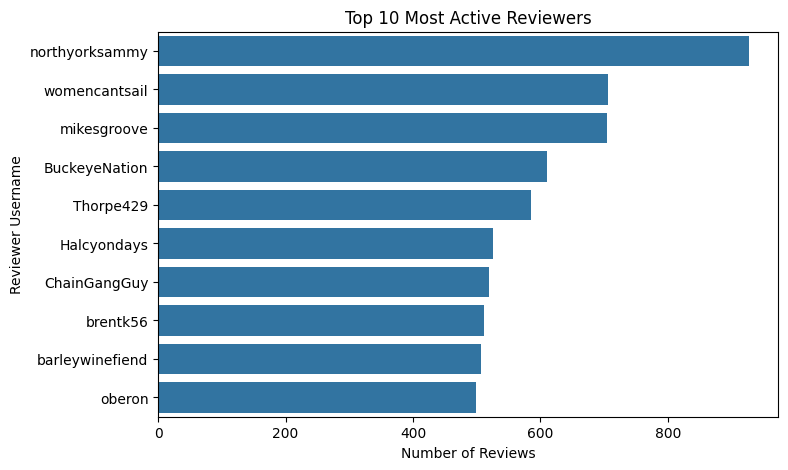

In [15]:
top_reviewers = review_counts.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index
)

plt.title("Top 10 Most Active Reviewers")
plt.xlabel("Number of Reviews")
plt.ylabel("Reviewer Username")

plt.show()

## Reviewer Bias Analysis

In this section, we analyze whether some reviewers consistently give higher or lower ratings than others.

We calculate:
- The average rating given by each reviewer
- The total number of reviews written

This helps identify generous reviewers and stricter critics.

In [ ]:
reviewer_stats = df.groupby("reviewer_username")["overall_score"].agg(["mean", "count"])

reviewer_stats.head()


,mean,count
reviewer_username,,
0110x011,4.121622,37
100floods,4.070597,32
1759Girl,3.853657,34
1Adam12,3.766001,27
1fastz28,3.758964,55


### Filtering Experienced Reviewers

Some reviewers have written only a few reviews, which may not represent reliable rating behavior.

To ensure meaningful analysis, we only consider reviewers who have written **at least 20 reviews**.

In [27]:

reviewer_stats = reviewer_stats[reviewer_stats["count"] >= 20]

### Generous Reviewers

These reviewers tend to give higher ratings on average.

In [23]:
reviewer_stats.sort_values("mean", ascending=False).head(10)

,mean,count
reviewer_username,,
kdawg105,4.688495,26
lemasney,4.615474,28
EnojysAnyBeer,4.504472,57
SDtastentune,4.503260,26
Sudsdog,4.485505,30
bitterthebetter,4.477975,22
bohemiandonut,4.475000,20
mempath,4.467238,57
pastradul,4.460000,25


### Strict Reviewers

These reviewers tend to give lower ratings and may have higher standards when evaluating beers.

In [25]:
reviewer_stats.sort_values("mean").head(10)

,mean,count
reviewer_username,,
AlexLMS,2.544118,34
B967ierhunter177,2.623389,25
Vendetta,2.709785,25
TerryW,2.776796,97
Arbitrator,2.801372,205
rastaman,2.821671,203
kojevergas,2.826170,141
ernie,2.871142,38
mwrseeley,2.875000,20


### Reviewer Experience vs Rating Behavior

In this section, we examine whether reviewers who have written more reviews tend to give higher or lower ratings.

If experienced reviewers tend to give lower average ratings, it may suggest that they develop stricter standards over time.

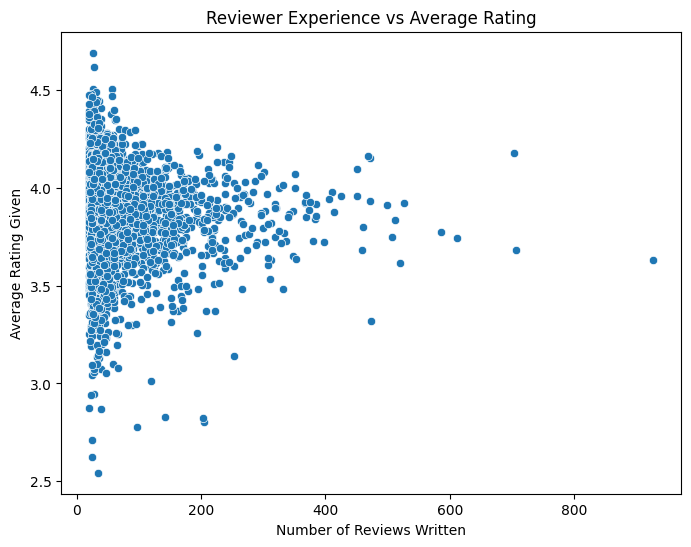

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=reviewer_stats["count"],
    y=reviewer_stats["mean"]
)

plt.xlabel("Number of Reviews Written")
plt.ylabel("Average Rating Given")
plt.title("Reviewer Experience vs Average Rating")

plt.show()

### Insight from Reviewer Experience vs Rating

The scatter plot shows the relationship between reviewer experience and the average rating they give.

Most reviewers in the dataset write fewer than 100 reviews, indicating that the majority of users are casual reviewers. Only a small group of reviewers contributes a large number of reviews.

Average ratings generally fall between 3.5 and 4.2, suggesting that reviewers tend to rate beers positively overall.

Reviewers with a large number of reviews tend to give more moderate ratings, indicating that experienced reviewers may develop stricter or more balanced evaluation standards over time.

### Reviewer Consistency

We measure how consistent reviewers are in their rating behavior by calculating the standard deviation of the ratings they give.

- A **low standard deviation** means the reviewer gives similar ratings most of the time (consistent).
- A **high standard deviation** means the reviewer gives very different ratings across beers (less consistent).

In [31]:
reviewer_consistency = df.groupby("reviewer_username")["overall_score"].std()
reviewer_consistency = reviewer_consistency.loc[reviewer_stats.index]
reviewer_consistency.head()

reviewer_username
0110x011     0.758337
100floods    0.649330
1759Girl     0.690223
1Adam12      0.687938
1fastz28     0.743865
Name: overall_score, dtype: float64

In [32]:
reviewer_consistency.sort_values().head(10)

reviewer_username
cpmichael          0.234601
BWMKappaSig        0.242817
sraimondi          0.243950
ngeunit1           0.244702
wethorseblanket    0.246626
beerorRIP          0.257272
neenerzig          0.263050
birderbeerer       0.264727
BeerForMuscle      0.267679
plaztikjezuz       0.274272
Name: overall_score, dtype: float64

In [33]:
reviewer_consistency.sort_values(ascending=False).head(10)

reviewer_username
KyleVick4         1.375999
Weizenmensch      1.296342
davod23           1.250891
xare              1.233021
4000qtrap         1.231893
kindestcut        1.195229
ggroller          1.170920
Erdinger2003      1.149752
JudgeRoughneck    1.133804
bierguru          1.131702
Name: overall_score, dtype: float64

### Reviewer Consistency Analysis

Reviewer consistency was measured using the standard deviation of ratings given by each reviewer.

Reviewers such as **cpmichael**, **BWMKappaSig**, and **sraimondi** show very low standard deviation values, indicating highly consistent rating behavior. These reviewers tend to give ratings that remain close to their average.

In contrast, reviewers like **KyleVick4**, **Weizenmensch**, and **davod23** have much higher standard deviation values, meaning their ratings vary widely across different beers.

This suggests that while some reviewers follow a stable evaluation pattern, others display more variability in their scoring, reflecting different reviewing styles and preferences.

### Distribution of Overall Ratings

We examine the distribution of overall beer ratings to understand how reviewers generally rate beers in the dataset.

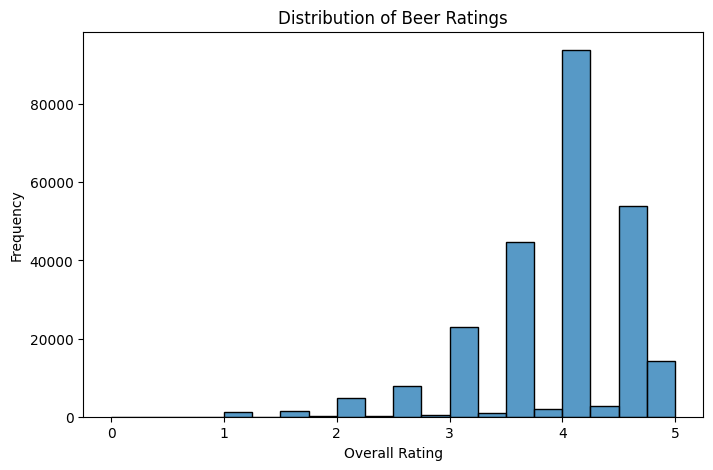

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["overall_score"], bins=20)

plt.title("Distribution of Beer Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")

plt.show()

### Distribution of Beer Ratings

The histogram shows that most beer ratings fall between **3.5 and 4.5**, with a strong concentration around **4.0–4.3**. This indicates that reviewers generally rate beers positively.

Very low ratings are relatively rare, suggesting that reviewers may be more likely to review beers they enjoy or that the reviewing community tends to evaluate beers favorably.

Although some beers receive ratings close to **5.0**, these occur less frequently, indicating that reviewers reserve the highest ratings for exceptional beers.

Overall, the distribution suggests a positive bias in beer ratings, with most reviews reflecting favorable opinions.

## Final Insights — Reviewer Behavior Analysis

The analysis of reviewer behavior reveals several important patterns in the beer review dataset.

### Reviewer Activity
The distribution of reviews shows that a small number of reviewers contribute a disproportionately large number of reviews. Reviewers such as **northyorksammy** have written hundreds of reviews, while most reviewers contribute far fewer. This indicates that a small group of highly active users dominates the reviewing activity in the dataset.

### Reviewer Bias
Analysis of average reviewer ratings shows that some reviewers consistently give higher scores while others tend to rate beers more strictly. For example, reviewers like **kdawg105** and **lemasney** tend to give very high average ratings, suggesting a more generous rating style. In contrast, reviewers such as **AlexLMS** and **B967ierhunter177** have lower average ratings, indicating stricter evaluation standards.

### Reviewer Experience vs Rating Behavior
The scatter plot comparing the number of reviews written and the average rating suggests that reviewers with greater experience tend to give more moderate ratings. While newer reviewers sometimes give extremely high ratings, experienced reviewers tend to rate beers more conservatively, suggesting that they develop more refined or critical judgment over time.

### Reviewer Consistency
Consistency analysis using the standard deviation of reviewer ratings shows that some reviewers maintain very stable rating patterns, while others display greater variability. Reviewers with lower standard deviation values, such as **cpmichael** and **BWMKappaSig**, tend to give consistent ratings across beers, whereas reviewers with higher variation show less predictable rating behavior.

### Overall Rating Distribution
The distribution of beer ratings shows that most ratings fall between **3.5 and 4.5**, with a strong concentration around **4.0**. Very low ratings are relatively rare, indicating that reviewers generally rate beers positively. This suggests a potential positive bias in the reviewing community.

### Overall Conclusion
Overall, the analysis demonstrates that reviewer behavior plays a significant role in shaping rating patterns within the dataset. A small group of highly active reviewers contributes many of the reviews, while individual rating styles vary between generous, strict, and consistent reviewers. Experienced reviewers tend to provide more balanced evaluations, and the overall rating distribution indicates that beer reviews are generally positive.